# Exploratory Data Analysis (EDA)
### DecodeLabs | Data Analytics Internship – Project 2
---

**Analysis Roadmap:**
1. Dataset Overview
2. Descriptive Statistics
3. Distribution Analysis
4. Trend Analysis (Time Series)
5. Category Breakdowns
6. Outlier Detection (IQR + Z-Score)
7. Correlation Analysis
8. Key Observations & Business Insights


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})


## 1. Dataset Overview
> Loading the cleaned dataset (Project 1 fixes applied inline).

In [18]:

df = pd.read_csv(r"C:\Hazem\DecodeLabs\Project2\Dataset for Data Analytics - Sheet1.csv")

#Apply Project 1 cleaning
df['Date']       = pd.to_datetime(df['Date'], errors='coerce')
df['CouponCode'] = df['CouponCode'].fillna('NONE')

for col in ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']:
    df[col] = df[col].astype(str).str.strip().str.title()

for col in ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Month']      = df['Date'].dt.to_period('M')
df['Year']       = df['Date'].dt.year
df['MonthName']  = df['Date'].dt.strftime('%b')

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Period : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print()
print(df.head())


Shape  : 1,200 rows × 17 columns
Period : 2023-01-01  →  2025-06-30

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice    Month  Year MonthName  
0   

In [19]:
#Column overview
info = pd.DataFrame({
    'dtype'  : df.dtypes.astype(str),
    'non_null': df.notnull().sum(),
    'nulls'  : df.isnull().sum(),
    'unique' : df.nunique(),
})
print(info.to_string())


                          dtype  non_null  nulls  unique
OrderID                  object      1200      0    1200
Date             datetime64[ns]      1200      0     671
CustomerID               object      1200      0    1189
Product                  object      1200      0       7
Quantity                  int64      1200      0       5
UnitPrice               float64      1200      0    1193
ShippingAddress          object      1200      0     655
PaymentMethod            object      1200      0       5
OrderStatus              object      1200      0       5
TrackingNumber           object      1200      0    1200
ItemsInCart               int64      1200      0      10
CouponCode               object      1200      0       4
ReferralSource           object      1200      0       5
TotalPrice              float64      1200      0    1195
Month                 period[M]      1200      0      30
Year                      int32      1200      0       3
MonthName                object

## 2. Descriptive Statistics
> Five-number summary (min, Q1, median, Q3, max) plus mean and std.

In [20]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']

desc = df[num_cols].describe().T
desc.index.name = 'Column'
desc.columns    = ['Count','Mean','Std','Min','Q1 (25%)','Median (50%)','Q3 (75%)','Max']

print("=" * 80)
print("FIVE-NUMBER SUMMARY + MEAN / STD")
print("=" * 80)
print(desc.round(2).to_string())


FIVE-NUMBER SUMMARY + MEAN / STD
              Count     Mean     Std    Min  Q1 (25%)  Median (50%)  Q3 (75%)      Max
Column                                                                                
Quantity     1200.0     2.95    1.41   1.00      2.00          3.00      4.00     5.00
UnitPrice    1200.0   356.41  197.18  11.39    186.06        364.21    521.57   699.93
TotalPrice   1200.0  1053.97  819.86  11.39    410.52        823.62   1578.48  3456.40
ItemsInCart  1200.0     5.48    2.28   1.00      4.00          5.00      7.00    10.00


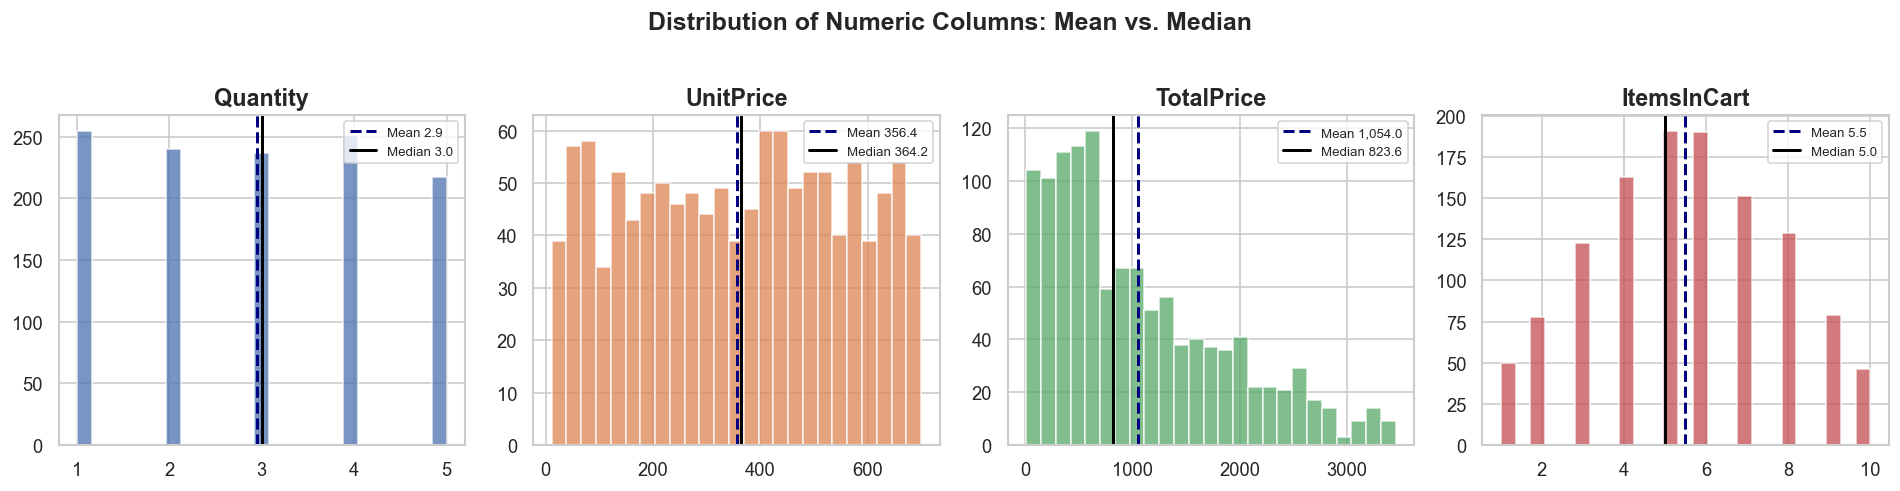

 When Mean > Median the distribution is right-skewed (pulled by high values).


In [21]:
# Mean vs Median comparison (skew check)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, color in zip(axes, num_cols, colors):
    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.hist(df[col].dropna(), bins=25, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(mean_val,   color='navy',   linestyle='--', linewidth=1.8, label=f'Mean {mean_val:,.1f}')
    ax.axvline(median_val, color='black',  linestyle='-',  linewidth=1.8, label=f'Median {median_val:,.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle("Distribution of Numeric Columns: Mean vs. Median", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plot_distributions.png", bbox_inches='tight')
plt.show()
print(" When Mean > Median the distribution is right-skewed (pulled by high values).")


## 3. Monthly Order & Revenue Trend
> How did order volume and revenue evolve over time?

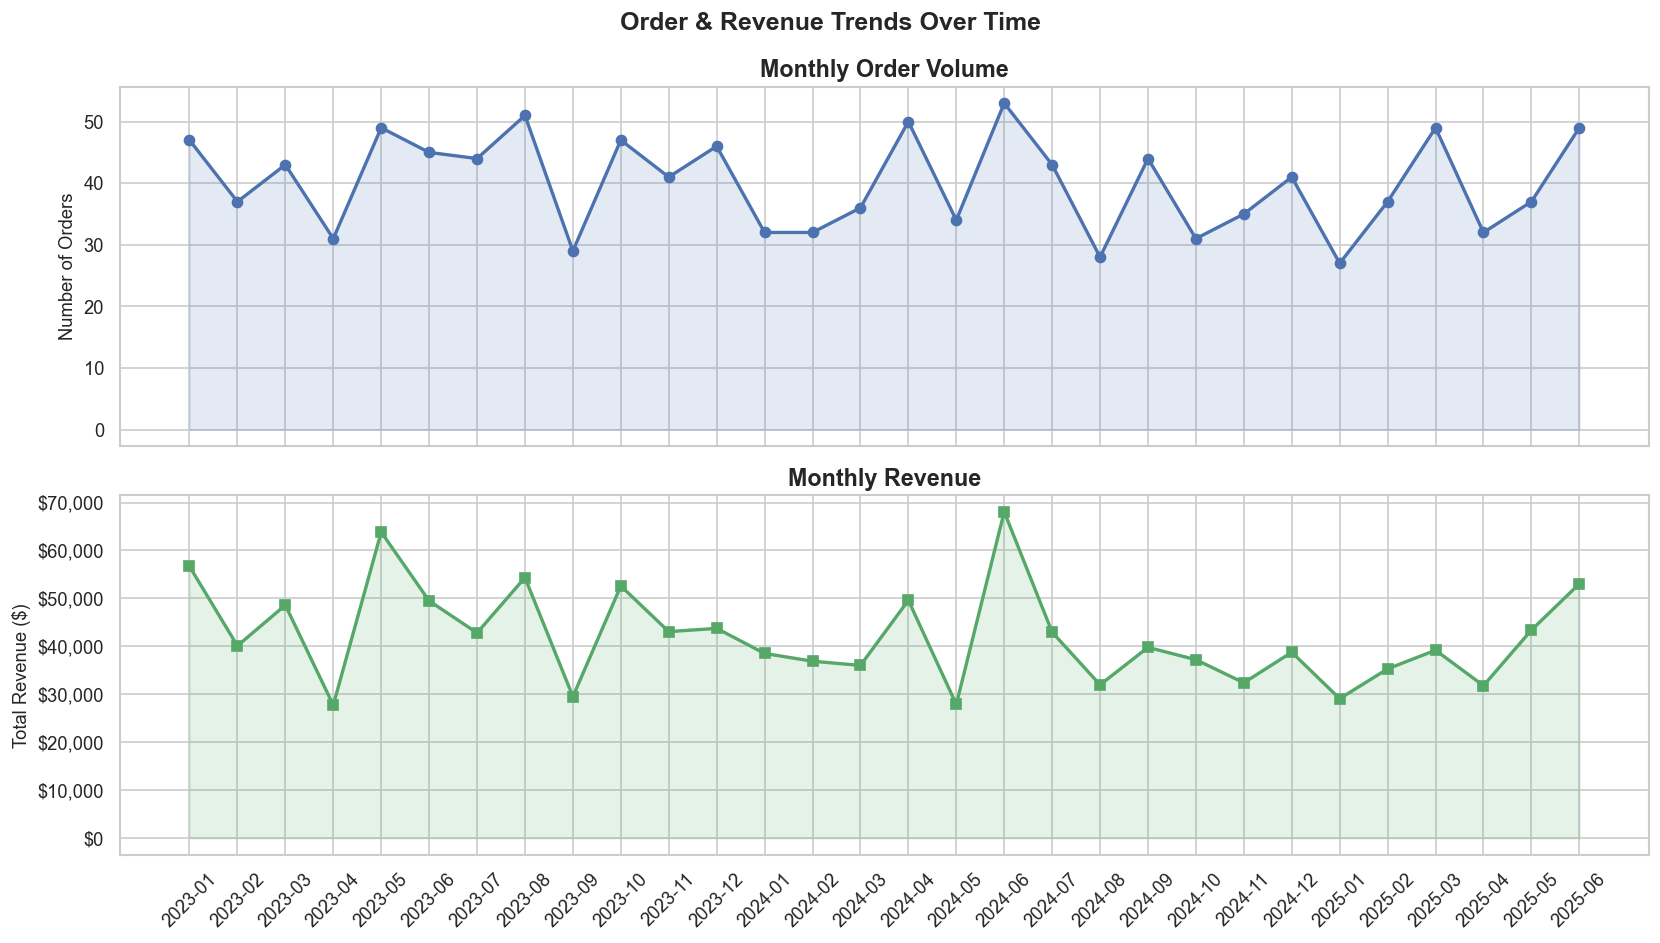

Peak month (orders) : 2024-06  →  53 orders
Peak month (revenue): 2024-06  →  $68,068.54


In [22]:
monthly = (df.groupby('Month')
             .agg(Orders=('OrderID','count'), Revenue=('TotalPrice','sum'))
             .reset_index())
monthly['Month_str'] = monthly['Month'].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Orders
ax1.plot(monthly['Month_str'], monthly['Orders'], marker='o', color='#4C72B0', linewidth=2)
ax1.fill_between(monthly['Month_str'], monthly['Orders'], alpha=0.15, color='#4C72B0')
ax1.set_ylabel("Number of Orders")
ax1.set_title("Monthly Order Volume")
ax1.tick_params(axis='x', rotation=45)

# Revenue
ax2.plot(monthly['Month_str'], monthly['Revenue'], marker='s', color='#55A868', linewidth=2)
ax2.fill_between(monthly['Month_str'], monthly['Revenue'], alpha=0.15, color='#55A868')
ax2.set_ylabel("Total Revenue ($)")
ax2.set_title("Monthly Revenue")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.tick_params(axis='x', rotation=45)

fig.suptitle("Order & Revenue Trends Over Time", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_trends.png", bbox_inches='tight')
plt.show()

print(f"Peak month (orders) : {monthly.loc[monthly['Orders'].idxmax(), 'Month_str']}  →  {monthly['Orders'].max()} orders")
print(f"Peak month (revenue): {monthly.loc[monthly['Revenue'].idxmax(), 'Month_str']}  →  ${monthly['Revenue'].max():,.2f}")


## 4. Category Breakdowns
> Which products, channels, and statuses dominate?

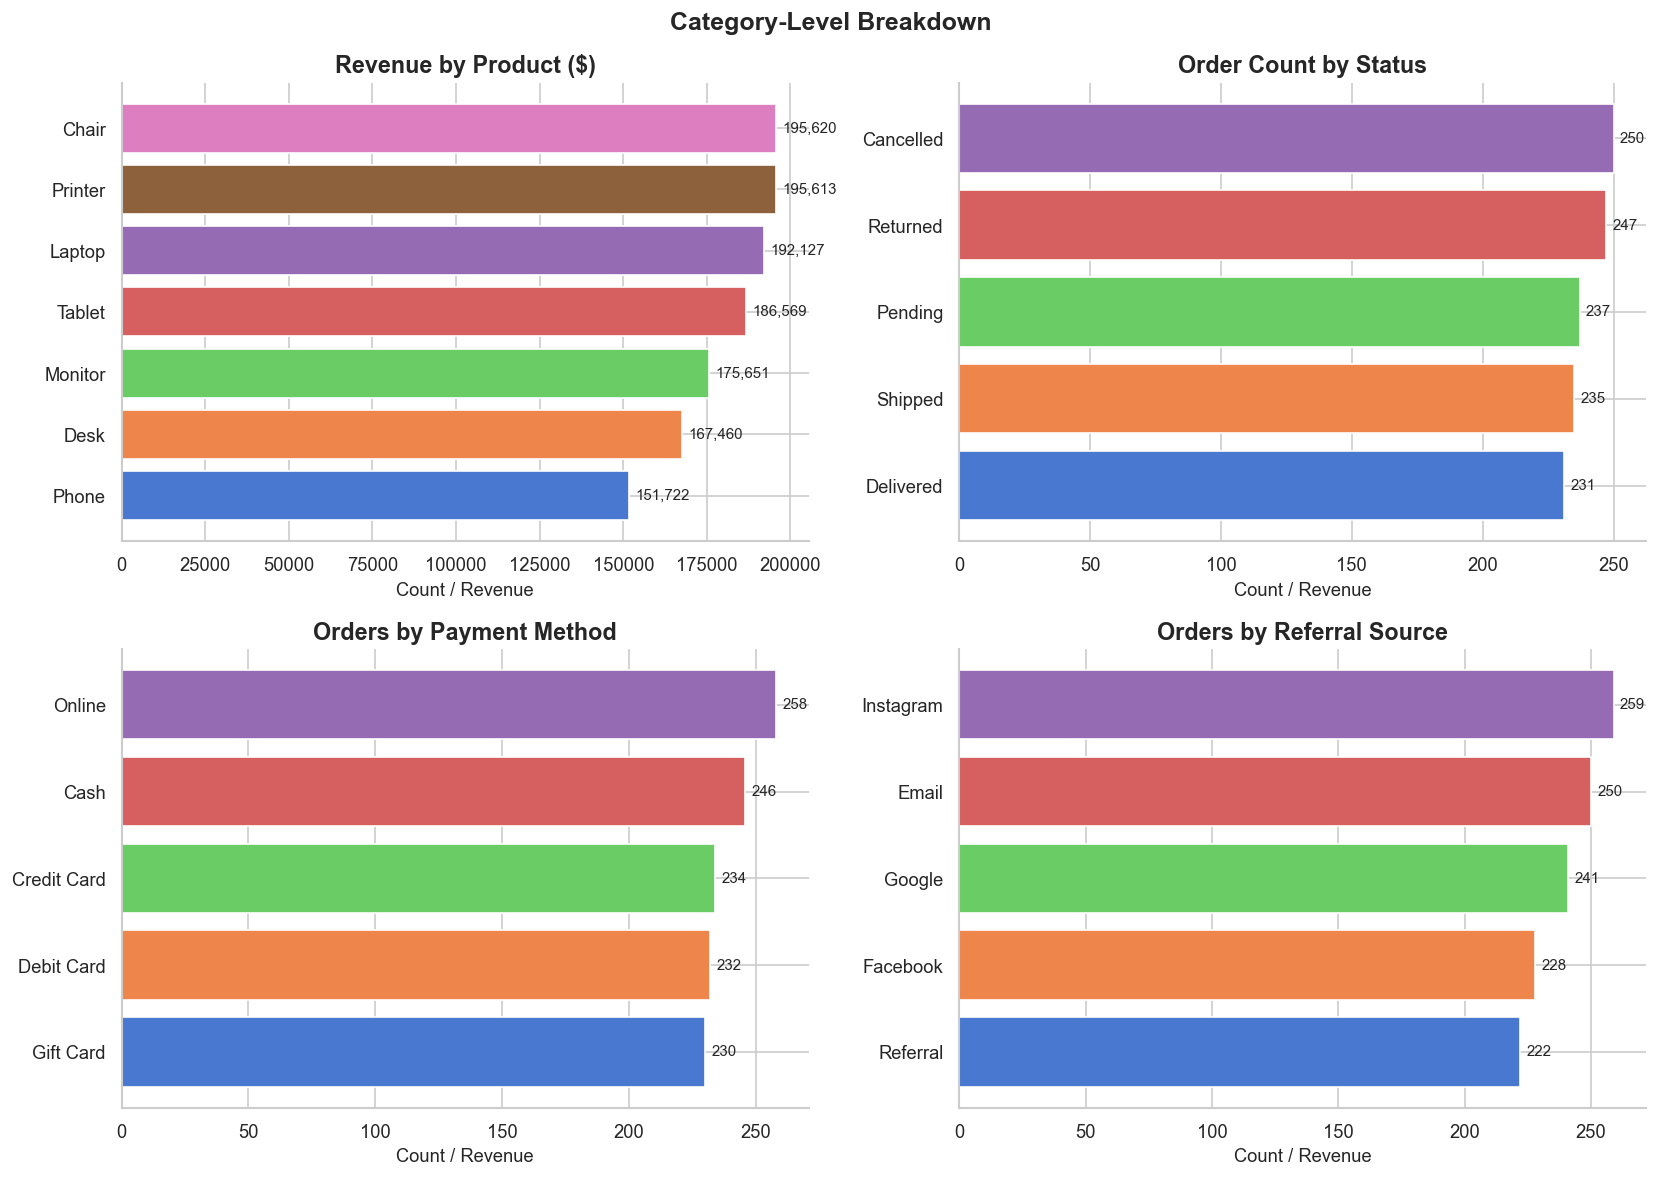

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_plots = [
    ('Product',       'Revenue by Product ($)',       df.groupby('Product')['TotalPrice'].sum().sort_values()),
    ('OrderStatus',   'Order Count by Status',        df['OrderStatus'].value_counts().sort_values()),
    ('PaymentMethod', 'Orders by Payment Method',     df['PaymentMethod'].value_counts().sort_values()),
    ('ReferralSource','Orders by Referral Source',    df['ReferralSource'].value_counts().sort_values()),
]

palette = sns.color_palette("muted", 8)

for ax, (col, title, data) in zip(axes.flat, cat_plots):
    bars = ax.barh(data.index, data.values, color=palette[:len(data)], edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Count / Revenue')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + data.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle("Category-Level Breakdown", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_categories.png", bbox_inches='tight')
plt.show()


## 5. Outlier Detection

Two methods are used (as taught in the DecodeLabs EDA framework):
- **IQR Method** — robust against extreme values; best for business data
- **Z-Score Method** — flags values > 3 standard deviations from the mean


In [24]:
# ── IQR Method ──
Q1  = df['TotalPrice'].quantile(0.25)
Q3  = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_outliers = df[(df['TotalPrice'] < lower_fence) | (df['TotalPrice'] > upper_fence)]

print("IQR OUTLIER DETECTION — TotalPrice")
print(f"  Q1 (25th pct) : ${Q1:,.2f}")
print(f"  Q3 (75th pct) : ${Q3:,.2f}")
print(f"  IQR           : ${IQR:,.2f}")
print(f"  Lower fence   : ${lower_fence:,.2f}")
print(f"  Upper fence   : ${upper_fence:,.2f}")
print(f"  Outliers found: {len(iqr_outliers)}")
print()
print(iqr_outliers[['OrderID','Product','Quantity','UnitPrice','TotalPrice']].to_string(index=False))


IQR OUTLIER DETECTION — TotalPrice
  Q1 (25th pct) : $410.52
  Q3 (75th pct) : $1,578.47
  IQR           : $1,167.95
  Lower fence   : $-1,341.41
  Upper fence   : $3,330.41
  Outliers found: 8

  OrderID Product  Quantity  UnitPrice  TotalPrice
ORD200107 Printer         5     670.75     3353.75
ORD200326  Laptop         5     670.48     3352.40
ORD200328  Tablet         5     674.04     3370.20
ORD200469   Chair         5     676.98     3384.90
ORD200632  Laptop         5     678.16     3390.80
ORD200789  Tablet         5     691.28     3456.40
ORD201065 Printer         5     666.80     3334.00
ORD201122 Monitor         5     678.19     3390.95


In [25]:
#Z-Score Method
df['z_TotalPrice'] = np.abs(stats.zscore(df['TotalPrice'].dropna()))
z_outliers = df[df['z_TotalPrice'] > 3]

print("Z-SCORE OUTLIER DETECTION — TotalPrice  (threshold |z| > 3)")
print(f"  Mean  : ${df['TotalPrice'].mean():,.2f}")
print(f"  Std   : ${df['TotalPrice'].std():,.2f}")
print(f"  Outliers found: {len(z_outliers)}")
if len(z_outliers):
    print(z_outliers[['OrderID','TotalPrice','z_TotalPrice']].to_string(index=False))
else:
    print(" No extreme statistical outliers (|z| > 3). Data spread is within normal range.")


Z-SCORE OUTLIER DETECTION — TotalPrice  (threshold |z| > 3)
  Mean  : $1,053.97
  Std   : $819.86
  Outliers found: 0
 No extreme statistical outliers (|z| > 3). Data spread is within normal range.


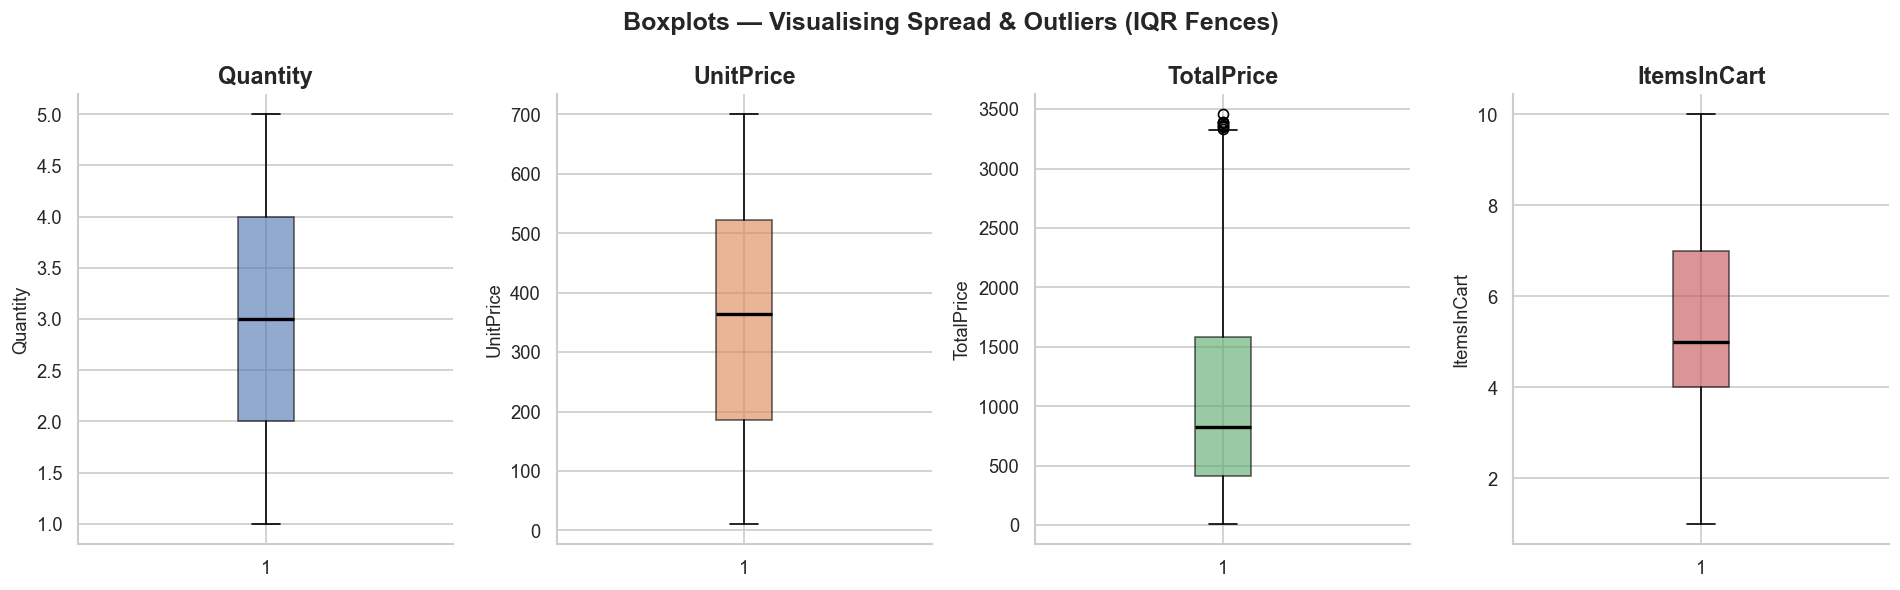

 Points beyond the whiskers are flagged as potential outliers by the IQR rule.


In [26]:
# Boxplot visualisation
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, color in zip(axes, num_cols, colors):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle("Boxplots — Visualising Spread & Outliers (IQR Fences)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_boxplots.png", bbox_inches='tight')
plt.show()
print(" Points beyond the whiskers are flagged as potential outliers by the IQR rule.")


## 6. Correlation Analysis
> Pearson Correlation Coefficient (r) measures the direction and strength of linear relationships.

In [27]:
corr = df[num_cols].corr()

print("PEARSON CORRELATION MATRIX")
print(corr.round(3).to_string())
print()
print("Interpretation guide:")
print("  |r| > 0.7 → Strong   |r| 0.4–0.7 → Moderate   |r| < 0.4 → Weak")


PEARSON CORRELATION MATRIX
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity        1.000      0.015       0.615        0.650
UnitPrice       0.015      1.000       0.717        0.001
TotalPrice      0.615      0.717       1.000        0.393
ItemsInCart     0.650      0.001       0.393        1.000

Interpretation guide:
  |r| > 0.7 → Strong   |r| 0.4–0.7 → Moderate   |r| < 0.4 → Weak


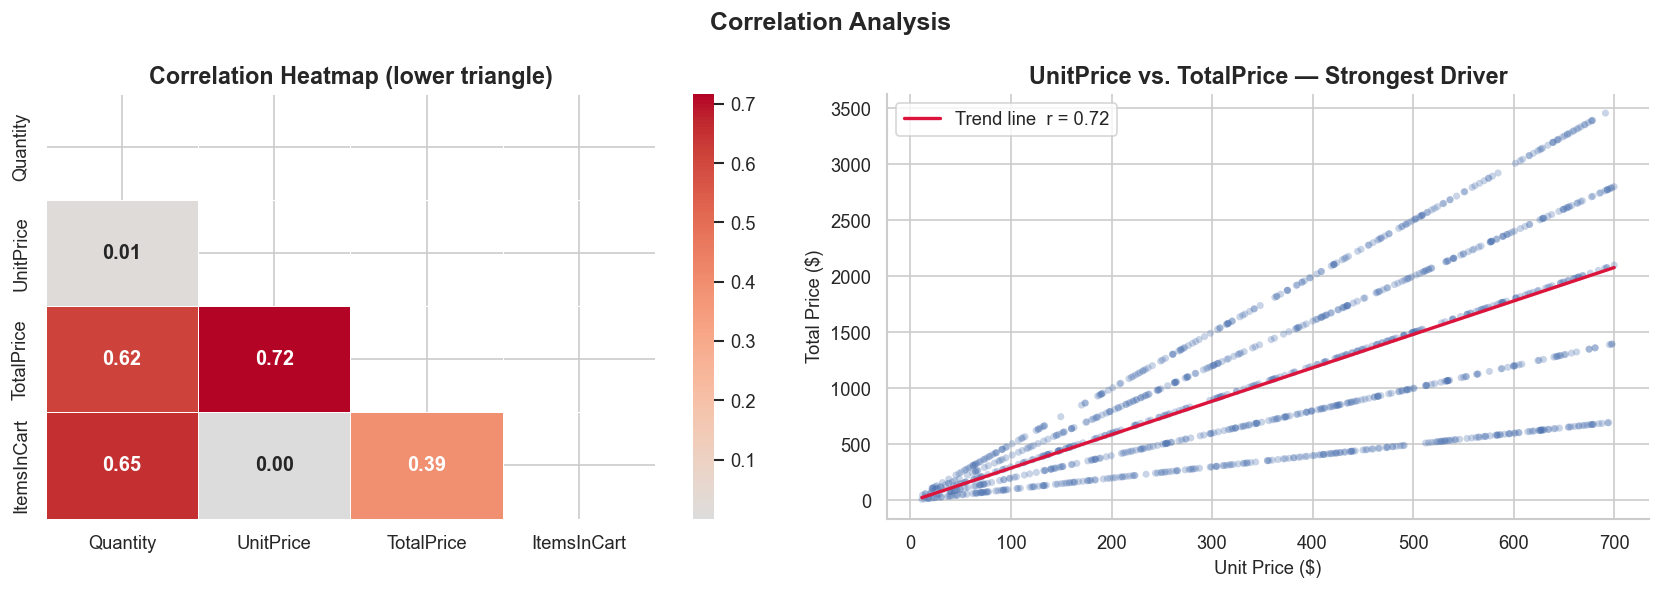

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], mask=mask,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title("Correlation Heatmap (lower triangle)")

# Scatter: UnitPrice vs TotalPrice (strongest non-trivial pair)
axes[1].scatter(df['UnitPrice'], df['TotalPrice'],
                alpha=0.3, color='#4C72B0', edgecolors='none', s=18)
m, b = np.polyfit(df['UnitPrice'], df['TotalPrice'], 1)
x_line = np.linspace(df['UnitPrice'].min(), df['UnitPrice'].max(), 100)
axes[1].plot(x_line, m*x_line + b, color='crimson', linewidth=2,
             label=f'Trend line  r = {corr.loc["UnitPrice","TotalPrice"]:.2f}')
axes[1].set_xlabel("Unit Price ($)")
axes[1].set_ylabel("Total Price ($)")
axes[1].set_title("UnitPrice vs. TotalPrice — Strongest Driver")
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle("Correlation Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_correlation.png", bbox_inches='tight')
plt.show()


## 7. Segment Deep-Dive
> Average order value and revenue split by product and order status.

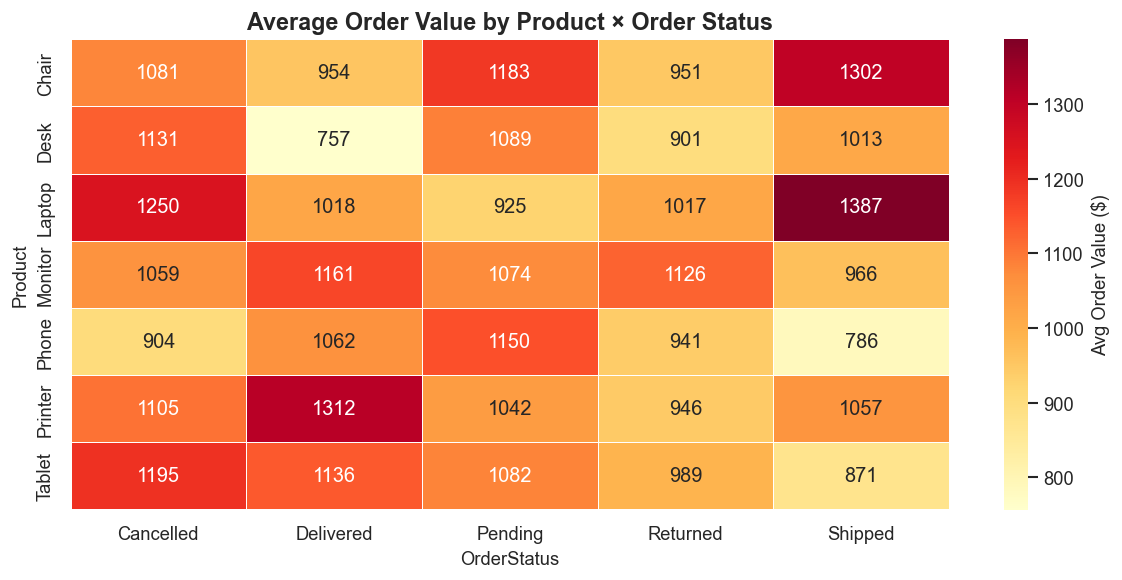

In [29]:
# Product × OrderStatus heatmap
pivot = df.pivot_table(values='TotalPrice', index='Product',
                       columns='OrderStatus', aggfunc='mean').round(0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Avg Order Value ($)'})
ax.set_title("Average Order Value by Product × Order Status", fontweight='bold')
plt.tight_layout()
plt.savefig("plot_segment_heatmap.png", bbox_inches='tight')
plt.show()


COUPON CODE IMPACT ON AVERAGE ORDER VALUE
            Avg Order ($)  Orders
CouponCode                       
Freeship          1070.41     313
Save10            1065.87     286
None              1043.37     309
Winter15          1035.90     292



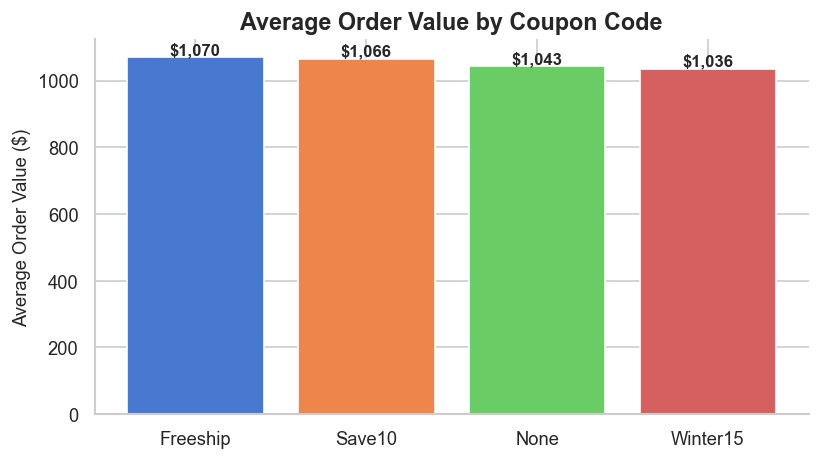

In [30]:
# Coupon impact on average order value
coupon_avg = (df.groupby('CouponCode')['TotalPrice']
               .agg(['mean','count'])
               .sort_values('mean', ascending=False)
               .rename(columns={'mean':'Avg Order ($)','count':'Orders'}))

print("COUPON CODE IMPACT ON AVERAGE ORDER VALUE")
print(coupon_avg.round(2).to_string())
print()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(coupon_avg.index, coupon_avg['Avg Order ($)'],
              color=sns.color_palette('muted', len(coupon_avg)), edgecolor='white')
for bar, val in zip(bars, coupon_avg['Avg Order ($)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel("Average Order Value ($)")
ax.set_title("Average Order Value by Coupon Code", fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("plot_coupon.png", bbox_inches='tight')
plt.show()


## 9. Export Summary Statistics

In [32]:
summary = {
    'total_orders'        : len(df),
    'total_revenue'       : df['TotalPrice'].sum().round(2),
    'avg_order_value'     : df['TotalPrice'].mean().round(2),
    'iqr_outliers'        : len(iqr_outliers),
    'cancelled_orders'    : (df['OrderStatus'] == 'Cancelled').sum(),
    'returned_orders'     : (df['OrderStatus'] == 'Returned').sum(),
    'top_product_revenue' : df.groupby('Product')['TotalPrice'].sum().idxmax(),
    'top_referral_source' : df['ReferralSource'].value_counts().idxmax(),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric','Value'])
print(summary_df.to_string(index=False))
summary_df.to_csv("eda_summary.csv", index=False)
print("\n eda_summary_v1.csv saved.")


             Metric       Value
       total_orders        1200
      total_revenue  1264761.96
    avg_order_value     1053.97
       iqr_outliers           8
   cancelled_orders         250
    returned_orders         247
top_product_revenue       Chair
top_referral_source   Instagram

 eda_summary_v1.csv saved.
